# Ejercicio 4: Modelo Probabilístico

## Objetivo de la práctica
- Comprender los componentes del modelo vectorial mediante cálculos manuales y observación directa.
- Aplicar el modelo de espacio vectorial con TF-IDF para recuperar documentos relevantes.
- Comparar la recuperación con BM25 frente a TF-IDF.
- Analizar visualmente las diferencias entre los modelos.
- Evaluar si los rankings generados son consistentes con lo que considerarías documentos relevantes.

* NOMBRE: FREDDY JIMENEZ
* FECHA: 03/05/2026

## Parte 0: Carga del Corpus

Utilizaremos el corpus `Gutenberg 1000`

In [1]:
import os

# ruta definida
path = r"C:\\Users\\fredd\\OneDrive\\Documentos\\GitHub\\RECUPERACIO_DE_LA_INFORMACION\\libros_gutenberg_es"
files = [f for f in os.listdir(path) if f.endswith('.txt')] # SOLO SE CARGAN LOS ARCHIVOS .TXT

corpus = []
filenames = []

for file in files:
    with open(os.path.join(path, file), 'r', encoding='utf-8') as f:
        corpus.append(f.read())
        filenames.append(file)

print(f"Total de documentos cargados: {len(corpus)}")

Total de documentos cargados: 1000


## Parte 1: Cálculo de TF, DF, IDF y TF-IDF

### Actividad 
1. Construye la matriz de términos (TF), y calcula la frecuencia de documentos (DF)

* CONSTRUCCION DE LA MATRIZ TF

In [4]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import numpy as np

# Construir matriz TF
vectorizer = CountVectorizer()
tf_matrix = vectorizer.fit_transform(corpus)

# Obtener términos
terminos = vectorizer.get_feature_names_out()

# DataFrame TF
df_tf = pd.DataFrame(tf_matrix.toarray(), index=filenames, columns=terminos)

print("MATRIZ TF (Term Frequency)")
print("Vista previa (primeros 5 documentos, primeras 10 términos):")
print(df_tf.iloc[:5, :10])

MATRIZ TF (Term Frequency)
Vista previa (primeros 5 documentos, primeras 10 términos):
                                                    00  000  0008  000th  001  \
7 de julio by Benito Pérez Galdós.txt                0    2     0      0    0   
A First Spanish Reader by Erwin W. Roessler and...   0   47     0      0    0   
A Flor De Piel_ Frases by Gustavo Sánchez Galar...   0    1     0      0    0   
A los pies de Venus (los Borgia) _  novela by V...   0   39     0      0    0   
A vuela pluma_ colección de artículos literario...   0   13     0      0    0   

                                                    0014  002  0022  0023m  \
7 de julio by Benito Pérez Galdós.txt                  0    0     0      0   
A First Spanish Reader by Erwin W. Roessler and...     0    0     0      0   
A Flor De Piel_ Frases by Gustavo Sánchez Galar...     0    0     0      0   
A los pies de Venus (los Borgia) _  novela by V...     0    0     0      0   
A vuela pluma_ colección de artículo

* CALCULO DE LA DF

In [5]:
# DF = cuántos documentos tienen el término
df_valores = (tf_matrix > 0).sum(axis=0).A1

# Calcular IDF con la fórmula de sklearn
n = len(corpus)  # número total de documentos
idf_sklearn = np.log((1 + n) / (1 + df_valores)) + 1

# DataFrame con resultados
df_analisis = pd.DataFrame({
    'Término': terminos,
    'DF': df_valores,
    'IDF_sklearn': idf_sklearn
}).sort_values('DF', ascending=False)

print("FRECUENCIA DE DOCUMENTOS (DF) e IDF (fórmula sklearn):")
print(df_analisis.head(20))

FRECUENCIA DE DOCUMENTOS (DF) e IDF (fórmula sklearn):
            Término    DF  IDF_sklearn
684233    trademark  1000          1.0
236703         cost  1000          1.0
1               000  1000          1.0
470693          may  1000          1.0
295348  educational  1000          1.0
295184     editions  1000          1.0
295178      edition  1000          1.0
615959      royalty  1000          1.0
615957    royalties  1000          1.0
293703       ebooks  1000          1.0
293701        ebook  1000          1.0
293515       easily  1000          1.0
293546         easy  1000          1.0
610866        right  1000          1.0
196463        cease  1000          1.0
200894       change  1000          1.0
724487         word  1000          1.0
724512         work  1000          1.0
250517         days  1000          1.0
724550        works  1000          1.0


2. Calcula TF-IDF utilizando sklearn.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# Calcular TF-IDF
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(corpus)

# Ver resultado
terminos = vectorizer.get_feature_names_out()
df_tfidf = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=filenames,
    columns=terminos
)

print(df_tfidf.iloc[:5, :10])

                                                     00       000  0008  \
7 de julio by Benito Pérez Galdós.txt               0.0  0.000393   0.0   
A First Spanish Reader by Erwin W. Roessler and...  0.0  0.009667   0.0   
A Flor De Piel_ Frases by Gustavo Sánchez Galar...  0.0  0.002447   0.0   
A los pies de Venus (los Borgia) _  novela by V...  0.0  0.003121   0.0   
A vuela pluma_ colección de artículos literario...  0.0  0.001435   0.0   

                                                    000th  001  0014  002  \
7 de julio by Benito Pérez Galdós.txt                 0.0  0.0   0.0  0.0   
A First Spanish Reader by Erwin W. Roessler and...    0.0  0.0   0.0  0.0   
A Flor De Piel_ Frases by Gustavo Sánchez Galar...    0.0  0.0   0.0  0.0   
A los pies de Venus (los Borgia) _  novela by V...    0.0  0.0   0.0  0.0   
A vuela pluma_ colección de artículos literario...    0.0  0.0   0.0  0.0   

                                                    0022  0023m  0024  
7 de julio by 

3. Visualiza los valores en un DataFrame para analizar las diferencias entre los términos.

In [9]:
print(df_tfidf.iloc[:5, :10])

                                                     00       000  0008  \
7 de julio by Benito Pérez Galdós.txt               0.0  0.000393   0.0   
A First Spanish Reader by Erwin W. Roessler and...  0.0  0.009667   0.0   
A Flor De Piel_ Frases by Gustavo Sánchez Galar...  0.0  0.002447   0.0   
A los pies de Venus (los Borgia) _  novela by V...  0.0  0.003121   0.0   
A vuela pluma_ colección de artículos literario...  0.0  0.001435   0.0   

                                                    000th  001  0014  002  \
7 de julio by Benito Pérez Galdós.txt                 0.0  0.0   0.0  0.0   
A First Spanish Reader by Erwin W. Roessler and...    0.0  0.0   0.0  0.0   
A Flor De Piel_ Frases by Gustavo Sánchez Galar...    0.0  0.0   0.0  0.0   
A los pies de Venus (los Borgia) _  novela by V...    0.0  0.0   0.0  0.0   
A vuela pluma_ colección de artículos literario...    0.0  0.0   0.0  0.0   

                                                    0022  0023m  0024  
7 de julio by 

In [10]:
print("Top 10 términos en el primer documento:")
print(df_tfidf.iloc[0].sort_values(ascending=False).head(10))

Top 10 términos en el primer documento:
de     0.522165
que    0.395227
la     0.357098
el     0.261502
en     0.238133
no     0.198559
los    0.177847
se     0.139552
con    0.123968
su     0.119715
Name: 7 de julio by Benito Pérez Galdós.txt, dtype: float64


## Parte 2: Ranking de documentos usando TF-IDF

### Actividad 

1. Dada una consulta, construye el vector de consulta
2. Calcula la similitud coseno entre la consulta y cada documento usando los vectores TF-IDF
3. Genera un ranking de los documentos ordenados por relevancia.
4. Muestra los resultados en una tabla.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# 1. Definir consulta
consulta = "aventura amor misterio" 

# 2. Transformar consulta usando el mismo vectorizador TF-IDF
vector_consulta = vectorizer.transform([consulta])

# 3. Calcular similitud coseno entre consulta y todos los documentos
similitudes = cosine_similarity(vector_consulta, tfidf_matrix).flatten()

# 4. Crear ranking
ranking = pd.DataFrame({
    'Documento': filenames,
    'Similitud': similitudes
}).sort_values('Similitud', ascending=False)

# 5. Mostrar resultados
print(f"Consulta: '{consulta}'")
print("\nRanking de documentos (top 10):")
print(ranking.head(10))

Consulta: 'aventura amor misterio'

Ranking de documentos (top 10):
                                             Documento  Similitud
204  El infierno del amor_ leyenda fantastica by Ma...   0.031826
725                    Lira Póstuma by Rubén Darío.txt   0.024723
173  El castigo sin venganza _  Tragedia by Lope de...   0.024644
519                                    libro_61415.txt   0.024188
806        Místicas; poesías by María Raquel Adler.txt   0.024188
21               Amores_ elegías amatorias by Ovid.txt   0.021684
346       Impresiones, Poesías by José Campo Arana.txt   0.021494
928  Teatro selecto, tomo 4 de 4 by Pedro Calderón ...   0.020905
502       Las paredes oyen by Juan Ruiz de Alarcón.txt   0.020411
268                 Espasmo by Federico De Roberto.txt   0.019932


In [12]:
# Mostrar top 5 documentos con su similitud
print("TOP 5 DOCUMENTOS MÁS RELEVANTES:")
print("="*60)
for i, row in ranking.head(5).iterrows():
    print(f"{i+1}. {row['Documento'][:60]}...")
    print(f"   Similitud: {row['Similitud']:.4f}")
    print()

TOP 5 DOCUMENTOS MÁS RELEVANTES:
205. El infierno del amor_ leyenda fantastica by Manuel Fernández...
   Similitud: 0.0318

726. Lira Póstuma by Rubén Darío.txt...
   Similitud: 0.0247

174. El castigo sin venganza _  Tragedia by Lope de Vega.txt...
   Similitud: 0.0246

520. libro_61415.txt...
   Similitud: 0.0242

807. Místicas; poesías by María Raquel Adler.txt...
   Similitud: 0.0242



## Parte 3: Ranking con BM25

### Actividad 

1. Implementa un sistema de recuperación usando el modelo BM25.
2. Usa la misma consulta del ejercicio anterior.
3. Calcula el score BM25 para cada documento y genera un ranking.
4. Compara manualmente con el ranking de TF-IDF.

### Algoritmo BM25:

1. Tokenización
2. Calcular longitudes de documentos y promedio de longitud
3. Calcular TF (frecuencia de término por documento)
4. Calcular DF (document frequency) e IDF de BM25
5. Definir los parámetros de BM25 (k1, b)
6. Implementar la función de score BM25 para un documento
7. Función para calcular la probabilidad para todos los documentos de la colección a partir de una query
8. Recuperar los documentos mejor puntuados (ranking)

In [15]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

# 1. Tokenización y preparación
vectorizer = CountVectorizer()
tf_matrix = vectorizer.fit_transform(corpus)
terminos = vectorizer.get_feature_names_out()

# 2. Longitudes de documentos y promedio
longitudes = np.array(tf_matrix.sum(axis=1)).flatten()
avg_longitud = np.mean(longitudes)

# 3. TF ya está en tf_matrix

# 4. DF e IDF de BM25
N = len(corpus)
df = np.array((tf_matrix > 0).sum(axis=0)).flatten()
idf = np.log((N - df + 0.5) / (df + 0.5) + 1)

# 5. Parámetros BM25
k1 = 1.5
b = 0.75

# 6 y 7. Función de score BM25
def bm25_score(query, doc_idx):
    query_tokens = query.lower().split()
    score = 0
    doc_len = longitudes[doc_idx]
    
    for token in query_tokens:
        if token in terminos:
            idx = np.where(terminos == token)[0][0]
            tf = tf_matrix[doc_idx, idx]
            
            numerador = tf * (k1 + 1)
            denominador = tf + k1 * (1 - b + b * (doc_len / avg_longitud))
            score += idf[idx] * (numerador / denominador)
    
    return score

def buscar(query):
    scores = []
    for i in range(len(corpus)):
        scores.append(bm25_score(query, i))
    return np.array(scores)

# Consulta
consulta = "aventura amor misterio"

# 8. Recuperar ranking
scores = buscar(consulta)
ranking = pd.DataFrame({
    'Documento': filenames,
    'Score_BM25': scores
}).sort_values('Score_BM25', ascending=False)

print(f"Consulta: '{consulta}'")
print("\nRANKING BM25:")
print(ranking.head(10))

Consulta: 'aventura amor misterio'

RANKING BM25:
                                             Documento  Score_BM25
447  La opinión ajena _  (novela) by Eduardo Zamaco...    4.137624
988  Vida de Don Quijote y Sancho by Miguel de Unam...    4.091720
733        Los argonautas by Vicente Blasco Ibáñez.txt    4.014781
383            La Casa de los Cuervos by Hugo Wast.txt    4.012153
962  Un paseo por Paris, retratos al natural by Roq...    3.954385
786  Memorias de un vagón de ferrocarril by Eduardo...    3.951564
176  El cocinero de su majestad_ Memorias del tiemp...    3.937496
782  Meditaciones del Quijote by José Ortega y Gass...    3.924749
901    Ruecas de Marfil (Novelas) by Concha Espina.txt    3.894868
387           La cita_ novelas by Eduardo Zamacois.txt    3.888096


## Parte 4: Comparación visual entre TF-IDF y BM25

### Actividad 

1. Utiliza un gráfico de barras para visualizar los scores obtenidos por cada documento según TF-IDF y BM25.
2. Compara los rankings visualmente.
3. ¿Qué documentos obtienen scores más altos en un modelo que en otro?
4. ¿A qué se podría deber esta diferencia?

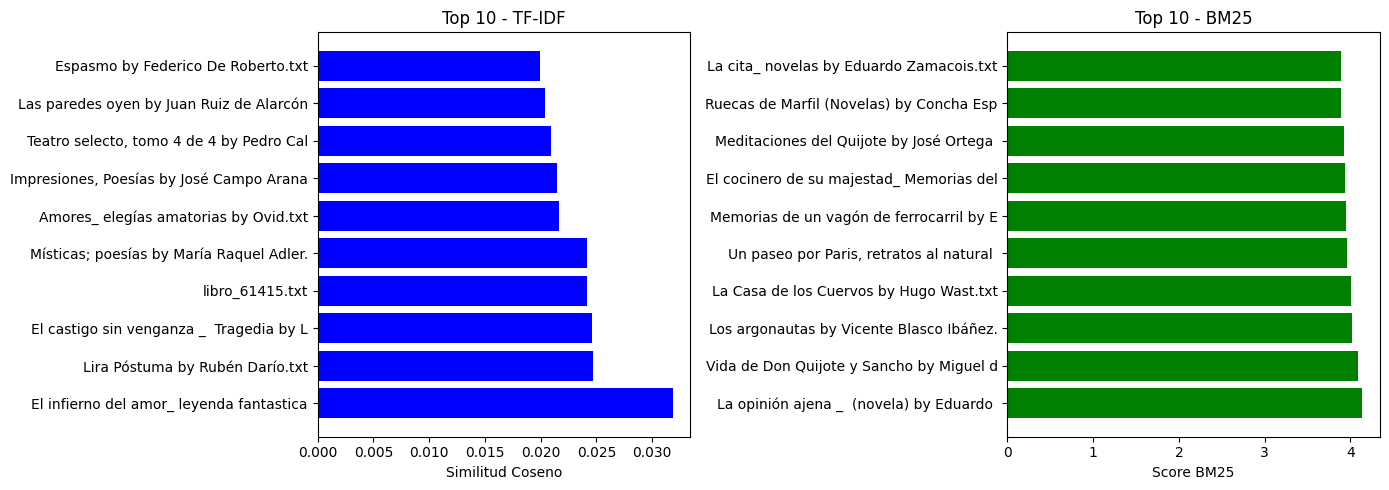

In [ ]:
# Comparar rankings TF-IDF y BM25
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico TF-IDF
axes[0].barh(ranking_tfidf.head(10)['Documento'].str[:40], 
             ranking_tfidf.head(10)['Similitud'], 
             color='blue')
axes[0].set_title('Top 10 - TF-IDF')
axes[0].set_xlabel('Similitud Coseno')

# Gráfico BM25
axes[1].barh(ranking_bm25.head(10)['Documento'].str[:40], 
             ranking_bm25.head(10)['Score_BM25'], 
             color='green')
axes[1].set_title('Top 10 - BM25')
axes[1].set_xlabel('Score BM25')

plt.tight_layout()
plt.show()

In [29]:
# Comparación visual de los rankings
print("COMPARACIÓN TOP 10 - TF-IDF vs BM25")
print("="*85)
print(f"{'Pos':<4} {'TF-IDF':<45} {'BM25':<45}")
print("-"*85)

for i in range(10):
    doc_tfidf = ranking_tfidf.iloc[i]['Documento'][:42]
    doc_bm25 = ranking_bm25.iloc[i]['Documento'][:42]
    print(f"{i+1:<4} {doc_tfidf:<45} {doc_bm25:<45}")

COMPARACIÓN TOP 10 - TF-IDF vs BM25
Pos  TF-IDF                                        BM25                                         
-------------------------------------------------------------------------------------
1    El infierno del amor_ leyenda fantastica b    La opinión ajena _  (novela) by Eduardo Za   
2    Lira Póstuma by Rubén Darío.txt               Vida de Don Quijote y Sancho by Miguel de    
3    El castigo sin venganza _  Tragedia by Lop    Los argonautas by Vicente Blasco Ibáñez.tx   
4    libro_61415.txt                               La Casa de los Cuervos by Hugo Wast.txt      
5    Místicas; poesías by María Raquel Adler.tx    Un paseo por Paris, retratos al natural by   
6    Amores_ elegías amatorias by Ovid.txt         Memorias de un vagón de ferrocarril by Edu   
7    Impresiones, Poesías by José Campo Arana.t    El cocinero de su majestad_ Memorias del t   
8    Teatro selecto, tomo 4 de 4 by Pedro Calde    Meditaciones del Quijote by José Ortega y    
9    

In [30]:
# Documentos que cambian de posición
print("\n" + "="*85)
print("DOCUMENTOS CON DIFERENCIAS NOTABLES:")
print("="*85)

for i in range(10):
    doc_tfidf = ranking_tfidf.iloc[i]['Documento']
    if doc_tfidf not in ranking_bm25.head(10)['Documento'].values:
        print(f"✓ '{doc_tfidf[:50]}'")
        print(f"  Está en top 10 de TF-IDF pero NO en top 10 de BM25\n")


DOCUMENTOS CON DIFERENCIAS NOTABLES:
✓ 'El infierno del amor_ leyenda fantastica by Manuel'
  Está en top 10 de TF-IDF pero NO en top 10 de BM25

✓ 'Lira Póstuma by Rubén Darío.txt'
  Está en top 10 de TF-IDF pero NO en top 10 de BM25

✓ 'El castigo sin venganza _  Tragedia by Lope de Veg'
  Está en top 10 de TF-IDF pero NO en top 10 de BM25

✓ 'libro_61415.txt'
  Está en top 10 de TF-IDF pero NO en top 10 de BM25

✓ 'Místicas; poesías by María Raquel Adler.txt'
  Está en top 10 de TF-IDF pero NO en top 10 de BM25

✓ 'Amores_ elegías amatorias by Ovid.txt'
  Está en top 10 de TF-IDF pero NO en top 10 de BM25

✓ 'Impresiones, Poesías by José Campo Arana.txt'
  Está en top 10 de TF-IDF pero NO en top 10 de BM25

✓ 'Teatro selecto, tomo 4 de 4 by Pedro Calderón de l'
  Está en top 10 de TF-IDF pero NO en top 10 de BM25

✓ 'Las paredes oyen by Juan Ruiz de Alarcón.txt'
  Está en top 10 de TF-IDF pero NO en top 10 de BM25

✓ 'Espasmo by Federico De Roberto.txt'
  Está en top 10 de TF-IDF p

3. **¿Qué documentos obtienen scores más altos en un modelo que en otro?**

*  TF-IDF: 'El infierno del amor' (similitud 0.0318)
* BM25: 'La opinión ajena' (score 4.1376)


 4. **¿A qué se podría deber esta diferencia?**

* BM25 aplica SATURACIÓN de frecuencia con k1=1.5
* BM25 normaliza por LONGITUD del documento con b=0.75
* TF-IDF usa normalización L2 (coseno) sin estos ajustes
* Documentos más largos o cortos son tratados diferente